# Ground Truth Dataset Analysis
Explore the categories and difficulty levels in the ground truth dataset.

In [18]:
import pandas as pd

df = pd.read_csv('ground_truth.csv')
print(f'Total questions: {len(df)}')
print(f'Columns: {list(df.columns)}')
df.head()

Total questions: 200
Columns: ['Question Number', 'Question', 'Answer', 'Category', 'Difficulty', 'Skill', 'Job Role']


,Question Number,Question,Answer,Category,Difficulty,Skill,Job Role
0,1,What is the difference between compilation and...,Compilation translates source code into machin...,General Programming,Medium,Programming Fundamentals,Software Engineer
1,2,Explain the concept of polymorphism.,Polymorphism allows objects of different class...,General Programming,Medium,Programming Fundamentals,Software Engineer
2,3,Define encapsulation and give an example.,Encapsulation bundles data and methods in a cl...,General Programming,Hard,Programming Fundamentals,Software Engineer
3,4,"What is an abstract class, and how is it diffe...",An abstract class can't be instantiated and ca...,General Programming,Medium,Programming Fundamentals,Software Engineer
4,5,Describe the principles of Object-Oriented Pro...,"OOP principles include encapsulation, inherita...",General Programming,Medium,Programming Fundamentals,Software Engineer


## 1. Categories Overview

In [19]:
category_counts = df['Category'].value_counts()
print(f'Number of unique categories: {len(category_counts)}\n')
print('Questions per category:')
print(category_counts.to_string())

Number of unique categories: 21

Questions per category:
Category
System Design               24
DevOps                      21
Front-end                   17
Back-end                    14
Security                    13
Data Structures             11
Database and SQL            10
Languages and Frameworks    10
General Programming         10
Web Development             10
Version Control             10
Software Testing            10
Algorithms                  10
Full-stack                   8
Machine Learning             5
Distributed Systems          5
Networking                   3
Low-level Systems            3
Database Systems             3
Data Engineering             2
Artificial Intelligence      1


## 2. Difficulty Levels Overview

In [20]:
difficulty_counts = df['Difficulty'].value_counts()
print(f'Number of unique difficulty levels: {len(difficulty_counts)}\n')
print('Questions per difficulty:')
print(difficulty_counts.to_string())

Number of unique difficulty levels: 3

Questions per difficulty:
Difficulty
Medium    111
Hard       82
Easy        7


## 3. Difficulty Breakdown per Category
Cross-tabulation showing how many questions of each difficulty exist within each category.

In [21]:
cross_tab = pd.crosstab(df['Category'], df['Difficulty'], margins=True, margins_name='Total')
# reorder difficulty columns if they exist
desired_order = [c for c in ['Easy', 'Medium', 'Hard', 'Total'] if c in cross_tab.columns]
cross_tab = cross_tab[desired_order]
cross_tab

Difficulty,Easy,Medium,Hard,Total
Category,,,,
Algorithms,0,0,10,10
Artificial Intelligence,0,0,1,1
Back-end,1,11,2,14
Data Engineering,0,0,2,2
Data Structures,1,6,4,11
Database Systems,0,0,3,3
Database and SQL,1,7,2,10
DevOps,1,16,4,21
Distributed Systems,0,0,5,5


## 4. Visualization — Questions per Category

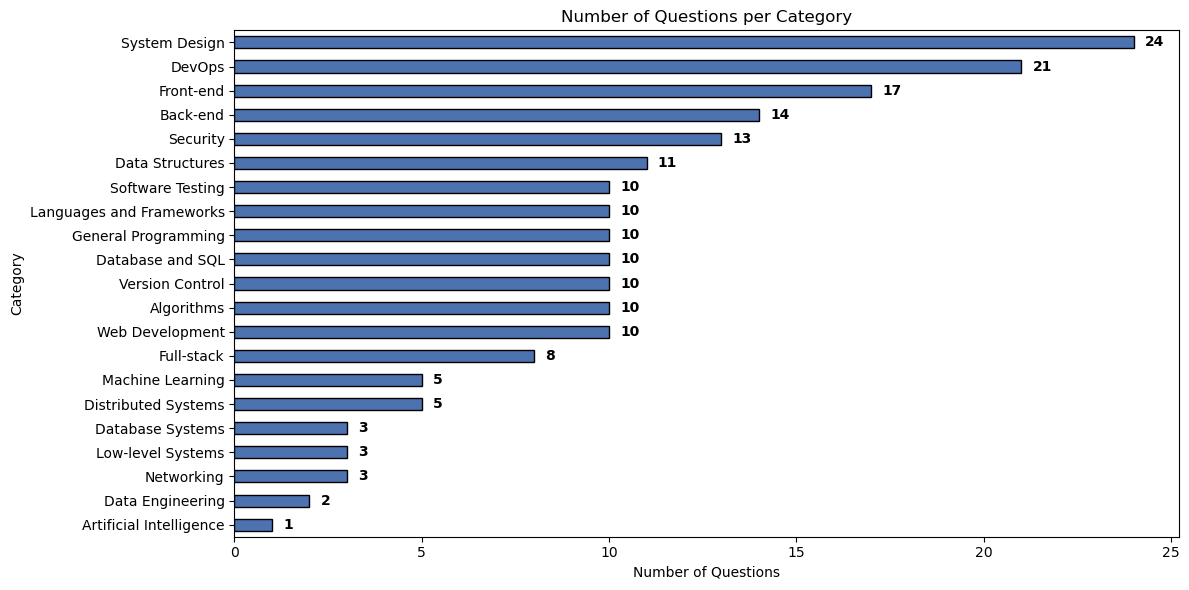

In [22]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 6))
category_counts.sort_values().plot(kind='barh', ax=ax, color='#4C72B0', edgecolor='black')
ax.set_xlabel('Number of Questions')
ax.set_ylabel('Category')
ax.set_title('Number of Questions per Category')
for i, v in enumerate(category_counts.sort_values()):
    ax.text(v + 0.3, i, str(v), va='center', fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Visualization — Difficulty Distribution per Category

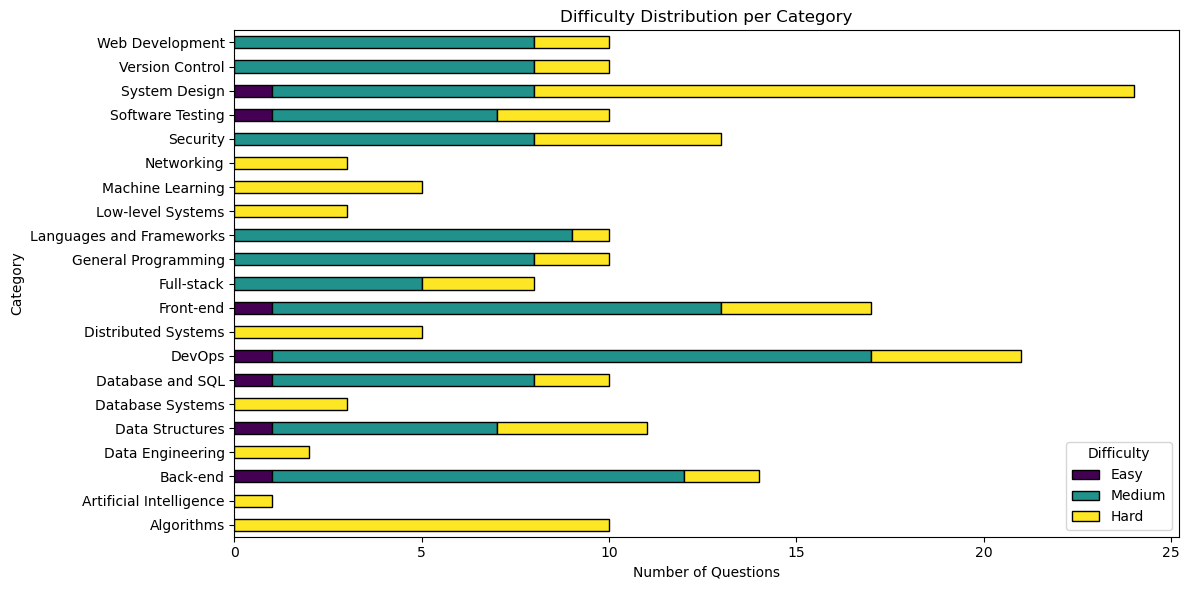

In [23]:
# Stacked bar chart
ct = pd.crosstab(df['Category'], df['Difficulty'])
desired = [c for c in ['Easy', 'Medium', 'Hard'] if c in ct.columns]
ct = ct[desired]

fig, ax = plt.subplots(figsize=(12, 6))
ct.plot(kind='barh', stacked=True, ax=ax, colormap='viridis', edgecolor='black')
ax.set_xlabel('Number of Questions')
ax.set_ylabel('Category')
ax.set_title('Difficulty Distribution per Category')
ax.legend(title='Difficulty')
plt.tight_layout()
plt.show()

## 7. Summary Table

In [24]:
summary = df.groupby('Category').agg(
    Total_Questions=('Question', 'count'),
    Difficulties=('Difficulty', lambda x: ', '.join(sorted(x.unique()))),
    Easy=('Difficulty', lambda x: (x == 'Easy').sum()),
    Medium=('Difficulty', lambda x: (x == 'Medium').sum()),
    Hard=('Difficulty', lambda x: (x == 'Hard').sum()),
).sort_values('Total_Questions', ascending=False)

print(f'\nDataset contains {len(df)} questions across {df["Category"].nunique()} categories and {df["Difficulty"].nunique()} difficulty levels.\n')
summary


Dataset contains 200 questions across 21 categories and 3 difficulty levels.



,Total_Questions,Difficulties,Easy,Medium,Hard
Category,,,,,
System Design,24,"Easy, Hard, Medium",1,7,16
DevOps,21,"Easy, Hard, Medium",1,16,4
Front-end,17,"Easy, Hard, Medium",1,12,4
Back-end,14,"Easy, Hard, Medium",1,11,2
Security,13,"Hard, Medium",0,8,5
Data Structures,11,"Easy, Hard, Medium",1,6,4
Web Development,10,"Hard, Medium",0,8,2
Algorithms,10,Hard,0,0,10
Version Control,10,"Hard, Medium",0,8,2


## 7. Job Role Overview


In [25]:
job_role_counts = df['Job Role'].value_counts()
print(f'Number of unique job roles: {len(job_role_counts)}\n')
print('Questions per job role:')
print(job_role_counts.to_string())


Number of unique job roles: 17

Questions per job role:
Job Role
Software Engineer               51
System Architect                24
DevOps Engineer                 21
Frontend Developer              17
Backend Developer               14
Cybersecurity Engineer          13
QA Engineer                     10
Database Administrator          10
Web Developer                   10
Full-stack Developer             8
Machine Learning Engineer        5
Distributed Systems Engineer     5
Network Engineer                 3
Systems Programmer               3
Database Engineer                3
Data Engineer                    2
AI Engineer                      1


## Merge Columns together

In [26]:
import pandas as pd

df = pd.read_csv('ground_truth.csv')
df['Job Role'] = df['Job Role'].replace('Web Developer', 'Full-stack Developer')
df.to_csv('ground_truth.csv', index=False)
print('Done!')


Done!


## Difficulty Breakdown per Job Role


In [27]:
cross_tab_role = pd.crosstab(df['Job Role'], df['Difficulty'], margins=True, margins_name='Total')
desired_order_role = [c for c in ['Easy', 'Medium', 'Hard', 'Total'] if c in cross_tab_role.columns]
cross_tab_role = cross_tab_role[desired_order_role]
cross_tab_role


Difficulty,Easy,Medium,Hard,Total
Job Role,,,,
AI Engineer,0,0,1,1
Backend Developer,1,11,2,14
Cybersecurity Engineer,0,8,5,13
Data Engineer,0,0,2,2
Database Administrator,1,7,2,10
Database Engineer,0,0,3,3
DevOps Engineer,1,16,4,21
Distributed Systems Engineer,0,0,5,5
Frontend Developer,1,12,4,17


## Categories mapped to each Job Role


In [28]:
role_category_map = df.groupby('Job Role')['Category'].apply(lambda x: ', '.join(sorted(x.unique())))
for role, cats in role_category_map.items():
    print(f"{role}: {cats}")


AI Engineer: Artificial Intelligence
Backend Developer: Back-end
Cybersecurity Engineer: Security
Data Engineer: Data Engineering
Database Administrator: Database and SQL
Database Engineer: Database Systems
DevOps Engineer: DevOps
Distributed Systems Engineer: Distributed Systems
Frontend Developer: Front-end
Full-stack Developer: Full-stack, Web Development
Machine Learning Engineer: Machine Learning
Network Engineer: Networking
QA Engineer: Software Testing
Software Engineer: Algorithms, Data Structures, General Programming, Languages and Frameworks, Version Control
System Architect: System Design
Systems Programmer: Low-level Systems


## Job Role Summary

In [29]:
role_summary = df.groupby('Job Role').agg(
    Total_Questions=('Question', 'count'),
    Categories=('Category', lambda x: ', '.join(sorted(x.unique()))),
    Difficulties=('Difficulty', lambda x: ', '.join(sorted(x.unique()))),
    Easy=('Difficulty', lambda x: (x == 'Easy').sum()),
    Medium=('Difficulty', lambda x: (x == 'Medium').sum()),
    Hard=('Difficulty', lambda x: (x == 'Hard').sum()),
).sort_values('Total_Questions', ascending=False)

print(f'\nDataset contains {len(df)} questions across {df["Job Role"].nunique()} job roles.\n')
role_summary



Dataset contains 200 questions across 16 job roles.



,Total_Questions,Categories,Difficulties,Easy,Medium,Hard
Job Role,,,,,,
Software Engineer,51,"Algorithms, Data Structures, General Programmi...","Easy, Hard, Medium",1,31,19
System Architect,24,System Design,"Easy, Hard, Medium",1,7,16
DevOps Engineer,21,DevOps,"Easy, Hard, Medium",1,16,4
Full-stack Developer,18,"Full-stack, Web Development","Hard, Medium",0,13,5
Frontend Developer,17,Front-end,"Easy, Hard, Medium",1,12,4
Backend Developer,14,Back-end,"Easy, Hard, Medium",1,11,2
Cybersecurity Engineer,13,Security,"Hard, Medium",0,8,5
Database Administrator,10,Database and SQL,"Easy, Hard, Medium",1,7,2
QA Engineer,10,Software Testing,"Easy, Hard, Medium",1,6,3
